> **Recorded AWS execution — 20260921-232118.** This notebook preserves the original code and scientific outputs. It is an evidence snapshot, not a claim that a data-free clone can rerun the private workspace. Start with [the portfolio overview](00_portfolio_overview.ipynb); see [reproduction instructions](../docs/REPRODUCIBILITY.md) and [current status](../docs/STATUS.md).


# 27 · Bidirectional temporal reassignment

**Official baseline:** 0.947; **last captured leader:** 0.974 (September 21, 17:51 UTC). No leaderboard request is made here.

## Why the previous direction stopped

All eight cached graph inputs had zero usable two-daughter proposals. The previous retention mechanism was therefore inapplicable; it is not retuned or applied in this experiment. The one completed comparison remains a negative result in Notebook 26.

## New hypothesis

A selected one-to-one edge can still connect the wrong trajectories. The reference motion assignment uses the preceding position and a damped forward velocity. We test whether **agreement from both past and future trajectory segments** can correct a small number of strongly inconsistent identity exchanges. This does not require the discarded dense learned probability matrix.

Temporal-context association is supported as a research direction by Gallusser & Weigert, *Trackastra*, ECCV 2024 / arXiv:2405.15700. This is an independently implemented geometric experiment, **not** a reproduction of Trackastra or the leaderboard leader.

## Frozen protocol

Five complete cached development movies, selected before this experiment, span two embryos. They were previously used by the public notebook; pretrained-model independence is unverified. This is exploratory screening, not independent validation or an official score.

In [1]:
from pathlib import Path
import json,warnings
import plotly.graph_objects as go
from IPython.display import Image,display
OUT=Path('/home/sagemaker-user/biohub-cell-tracking-during-development/outputs/competitive_gap_closure/temporal_reassignment')
def show(fig,height=560):
    fig.update_layout(width=1040,height=height,margin=dict(l=125,r=40,t=95,b=115))
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore',category=DeprecationWarning)
        png=fig.to_image(format='png',width=1040,height=height,scale=1)
    display(Image(data=png))

r=json.loads((OUT/'result.json').read_text())
assert r['status']=='complete' and len(r['measured_movies'])==5
assert r['model_fits']==r['main_network_inference_calls']==r['network_requests']==0
print('Measured movies:',', '.join(r['measured_movies']))
print('Decision:',r['decision'])
print('New frozen postprocessing runs:',r['new_frozen_postprocessing_runs'])
print('Reused frozen results:',r['reused_frozen'])


Measured movies: 44b6_12dfb391, 6bba_062c8d37, 44b6_267148e4, 6bba_07e24132, 44b6_2a2eff9f
Decision: stop_configuration_no_qualified_identity_exchanges
New frozen postprocessing runs: 4
Reused frozen results: 1


## What changes, and what does not

For each eligible edge, three detections before and three after the boundary estimate two-step velocities. Costs use **unsmoothed cached detection coordinates**. An exchange must improve both links by at least 0.75 µm, the total by at least 2 µm, and halve the total discrepancy. Each new forward and backward residual must be at most 2 µm; context acceleration must be at most 1.5 µm. The new step is limited to 10 µm. These are fixed screening settings, not fitted parameters.

Proposals use prediction-only information. Labels enter only after the candidate graph is saved. Accepted exchanges have disjoint six-frame contexts. Node coordinates, node counts, edge counts, individual node degrees, and existing division edges are invariant. New links do not inherit a fabricated learned probability. The original full postprocessing and the exact metric remain unchanged.

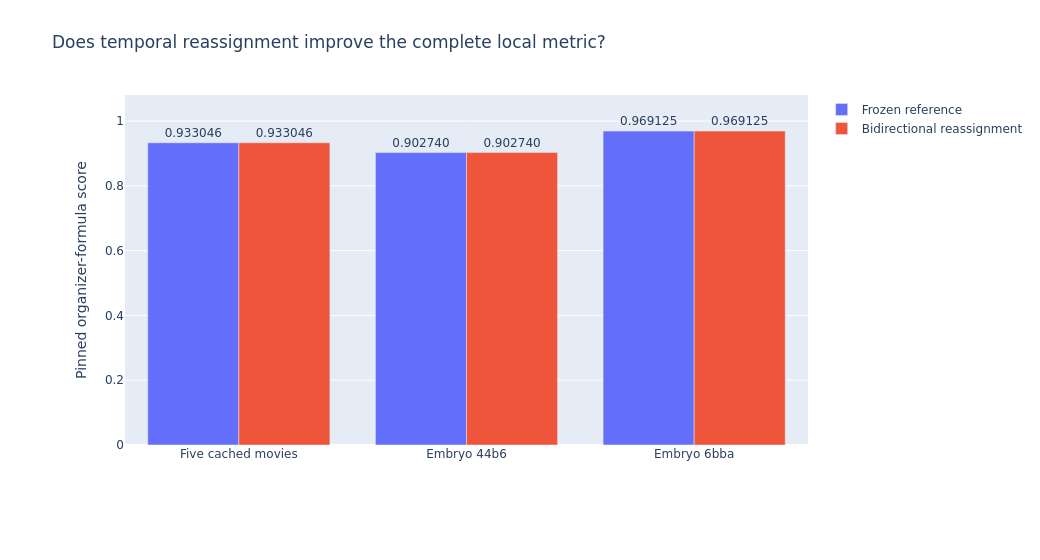

In [2]:
fig=go.Figure()
labels=['Five cached movies']+[f'Embryo {e}' for e in sorted(r['by_embryo'])]
for arm,label in [('frozen','Frozen reference'),('temporal_reassignment','Bidirectional reassignment')]:
    v=[r['summaries'][arm]['score']]+[r['by_embryo'][e][arm]['score'] for e in sorted(r['by_embryo'])]
    fig.add_bar(name=label,x=labels,y=v,text=[f'{x:.6f}' for x in v],textposition='outside')
fig.update_layout(title='Does temporal reassignment improve the complete local metric?',yaxis_title='Pinned organizer-formula score',barmode='group')
show(fig)


## Error trade-off

The metric uses sparse annotation-aware edge counts and topology-aware division scoring, not ordinary accuracy. A geometry improvement is not automatically a biological improvement. The frozen historical proxy is used only to check replay parity.

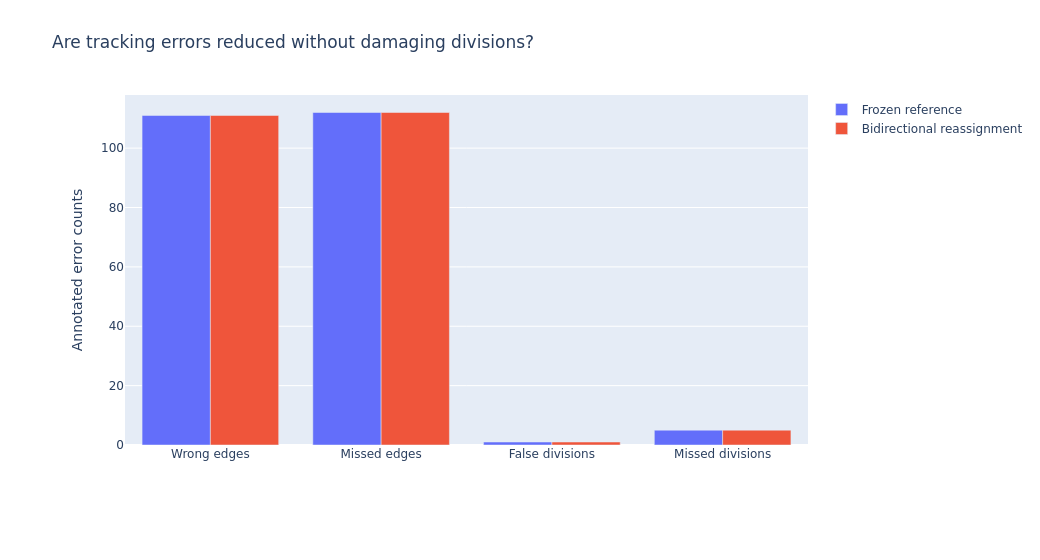

In [3]:
fig=go.Figure()
for arm,label in [('frozen','Frozen reference'),('temporal_reassignment','Bidirectional reassignment')]:
    rows=[x[arm]['metric'] for x in r['per_movie']]
    fig.add_bar(name=label,x=['Wrong edges','Missed edges','False divisions','Missed divisions'],y=[sum(v[k] for v in rows) for k in ['edge_fp','edge_fn','division_fp','division_fn']])
fig.update_layout(title='Are tracking errors reduced without damaging divisions?',yaxis_title='Annotated error counts',barmode='group')
show(fig)


## Where the candidate acts

Swapping two links is one intervention, not two recovered cells. These counts describe actions; only the evaluator above determines their benefit.

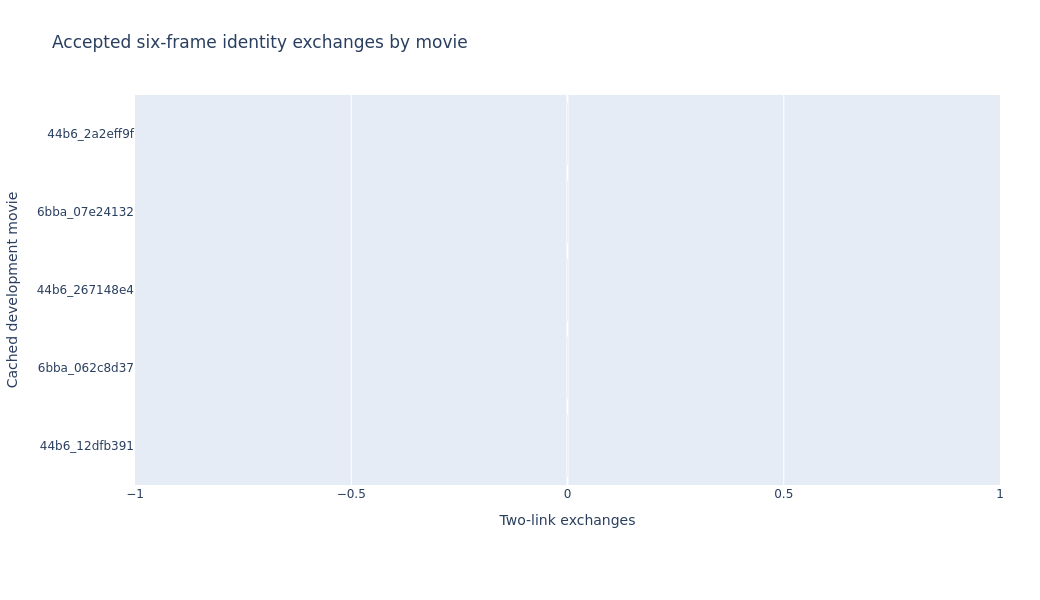

In [4]:
a=[x['temporal_reassignment']['audit'] for x in r['per_movie']]
fig=go.Figure(go.Bar(y=r['measured_movies'],x=[x['accepted_swaps'] for x in a],orientation='h'))
fig.update_layout(title='Accepted six-frame identity exchanges by movie',xaxis_title='Two-link exchanges',yaxis_title='Cached development movie')
show(fig,600)


## Decision

Screening requires at least 0.002 local combined-score improvement, adjusted-edge loss no worse than 0.0005, no loss for either embryo, no loss of division true positives or increase in false divisions, and at least one intervention. A passing screen earns independent confirmation only. A negative result retains the 0.947 reference; no sweep or automatic submission follows.

No training or main detector/transformer inference was run. Cached frozen graphs are reused; missing frozen graphs may require DeepCenter postprocessing on the AWS GPU. All downloads and external actions are disabled. Results are not a claim to have closed the official 0.027 gap.

In [5]:
print(json.dumps({k:r[k] for k in ['decision','score_delta','adjusted_edge_delta','embryo_deltas','accepted_swaps','screen_passed','approved_for_submission']},indent=2))
print('BIOHUB_TEMPORAL_REASSIGNMENT_NOTEBOOK_COMPLETE')

{
  "decision": "stop_configuration_no_qualified_identity_exchanges",
  "score_delta": 0.0,
  "adjusted_edge_delta": 0.0,
  "embryo_deltas": {
    "44b6": 0.0,
    "6bba": 0.0
  },
  "accepted_swaps": 0,
  "screen_passed": false,
  "approved_for_submission": false
}
BIOHUB_TEMPORAL_REASSIGNMENT_NOTEBOOK_COMPLETE
